# 1. Instalasi Library dan Import

In [3]:
!pip install transformers torch scikit-learn pandas numpy sastrawi

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.3 MB/s eta 0:00:00


# 2. Load Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('nlp.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

Saving nlp.csv to nlp.csv
(596, 2)
                                           full_text  \
0  Bimbingan Teknis Sistem Penghubung Layanan Pem...   
1  bagaimanakumaha udah lah metropolitan2 berak s...   
2  Sungguh sistem perbankan syariah di Aceh adala...   
3  Pemerintah Kota Pemkot Jakarta Pusat bersama P...   
4  SammiSoh Wah mas wali bobbynasution gimana itu...   

                                          text_clean  
0  bimbing teknis sistem hubung layan perintah yu...  
1  bagaimanakumaha metropolitan berak susah perin...  
2  sungguh sistem perban syariah aceh puncak tolo...  
3  perintah kota perintah kota jakarta pusat pt k...  
4  sammisoh mas wali bobbynasution perintah takut...  
['full_text', 'text_clean']


# 3. Pelabelan Sentimen menggunakan IndoBERT

In [5]:
from transformers import pipeline

# Load model
sentiment_pipeline = pipeline(
    "text-classification",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# Fungsi labeling
def get_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        label = result['label'].lower()
        if label == 'positive':
            return 1
        elif label == 'negative':
            return -1
        else:
            return 0
    except:
        return 0

# Labeling semua data (ini akan butuh beberapa menit)
print("Sedang melabeli data...")
df['sentiment'] = df['full_text'].apply(get_sentiment)
print("Selesai!")
print(df['sentiment'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Sedang melabeli data...
Selesai!
sentiment
 0    353
-1    170
 1     73
Name: count, dtype: int64


# 4. Feature Extraction (TF-IDF) dan Split Data

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X = tfidf.fit_transform(df['text_clean'])
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribusi train:", pd.Series(y_train).value_counts())

Train: (476, 5000) Test: (120, 5000)
Distribusi train: sentiment
 0    282
-1    136
 1     58
Name: count, dtype: int64


# 5. Oversampling dengan SMOTE dan Pelatihan Model Naive Bayes

In [7]:
# SMOTE hanya pada training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribusi setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# Model Naive Bayes
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_resampled, y_train_resampled)

# Evaluasi pada test data
y_pred = nb_model.predict(X_test)

print("\n=== EVALUASI PADA TEST DATA ===")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Distribusi setelah SMOTE:
sentiment
-1    282
 0    282
 1    282
Name: count, dtype: int64

=== EVALUASI PADA TEST DATA ===
              precision    recall  f1-score   support

    Negative       0.71      0.85      0.77        34
     Neutral       0.87      0.82      0.84        71
    Positive       0.50      0.40      0.44        15

    accuracy                           0.78       120
   macro avg       0.69      0.69      0.69       120
weighted avg       0.78      0.78      0.77       120

Confusion Matrix:
[[29  3  2]
 [ 9 58  4]
 [ 3  6  6]]


# 6. Visualisasi Hasil

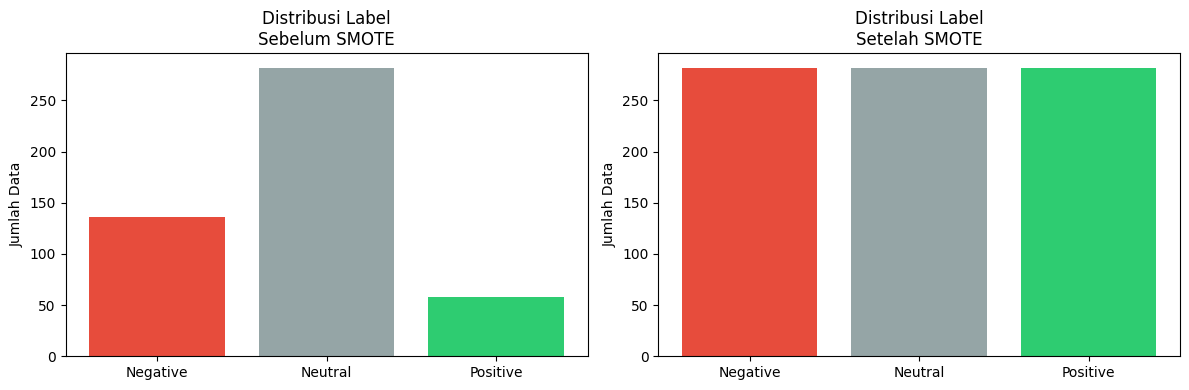

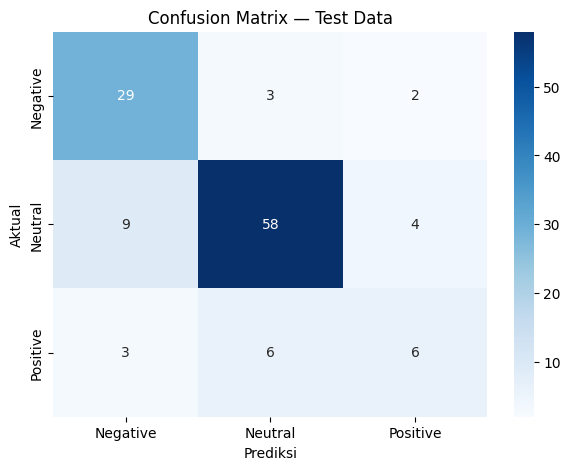

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribusi label sebelum dan sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_names = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
order = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

# Sebelum SMOTE
before = pd.Series(y_train).map(label_names).value_counts().reindex(order)
axes[0].bar(order, before.values, color=colors)
axes[0].set_title('Distribusi Label\nSebelum SMOTE')
axes[0].set_ylabel('Jumlah Data')

# Sesudah SMOTE
after = pd.Series(y_train_resampled).map(label_names).value_counts().reindex(order)
axes[1].bar(order, after.values, color=colors)
axes[1].set_title('Distribusi Label\nSetelah SMOTE')
axes[1].set_ylabel('Jumlah Data')

plt.tight_layout()
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix — Test Data')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# 7. Evaluasi F1-Score per Kelas

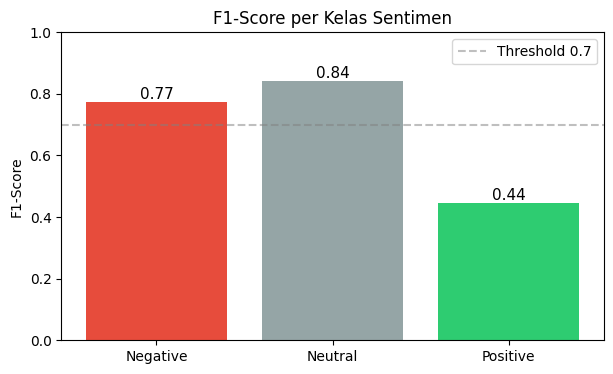

In [12]:
# 3. F1-Score per kelas
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred,
                                target_names=['Negative', 'Neutral', 'Positive'],
                                output_dict=True)

f1_scores = {
    'Negative': report['Negative']['f1-score'],
    'Neutral': report['Neutral']['f1-score'],
    'Positive': report['Positive']['f1-score']
}

plt.figure(figsize=(7, 4))
bars = plt.bar(f1_scores.keys(), f1_scores.values(),
               color=['#e74c3c', '#95a5a6', '#2ecc71'])

# Tambah angka di atas bar
for bar, val in zip(bars, f1_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', fontsize=11)

plt.title('F1-Score per Kelas Sentimen')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.7')
plt.legend()
plt.show()

#1. Membandingan dengan model SVM

=== EVALUASI SVM PADA TEST DATA ===
              precision    recall  f1-score   support

    Negative       0.77      0.68      0.72        34
     Neutral       0.78      0.90      0.84        71
    Positive       0.62      0.33      0.43        15

    accuracy                           0.77       120
   macro avg       0.72      0.64      0.66       120
weighted avg       0.76      0.77      0.75       120



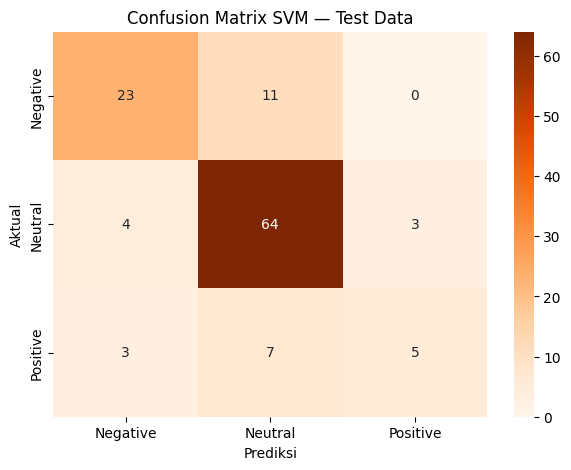

In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Model SVM
svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train_resampled, y_train_resampled)

# Evaluasi pada test data
y_pred_svm = svm_model.predict(X_test)

print("=== EVALUASI SVM PADA TEST DATA ===")
print(classification_report(y_test, y_pred_svm,
                            target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix SVM — Test Data')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

#2. Visualisasi Perbandingan Naive Bayes vs SVM

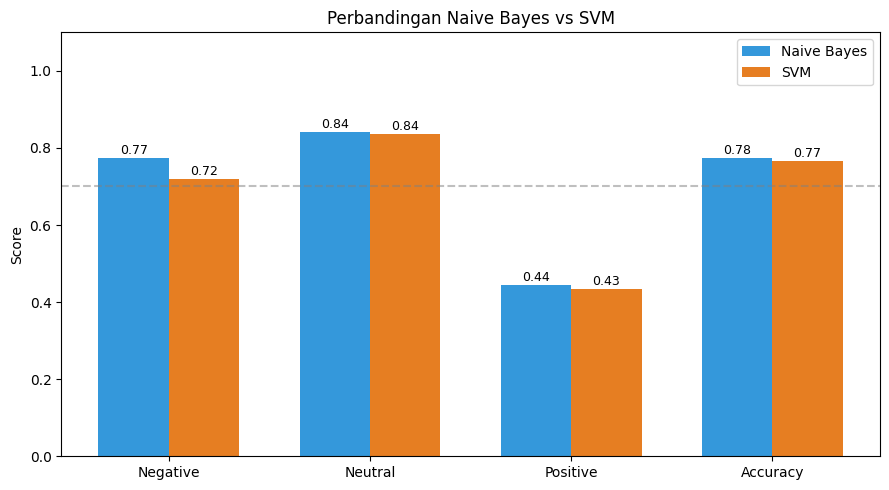

In [14]:
categories = ['Negative', 'Neutral', 'Positive', 'Accuracy']

nb_scores = [
    report['Negative']['f1-score'],
    report['Neutral']['f1-score'],
    report['Positive']['f1-score'],
    report['accuracy']
]

report_svm = classification_report(y_test, y_pred_svm,
                                    target_names=['Negative', 'Neutral', 'Positive'],
                                    output_dict=True)

svm_scores = [
    report_svm['Negative']['f1-score'],
    report_svm['Neutral']['f1-score'],
    report_svm['Positive']['f1-score'],
    report_svm['accuracy']
]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, nb_scores, width, label='Naive Bayes', color='#3498db')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM', color='#e67e22')

# Angka di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

ax.set_title('Perbandingan Naive Bayes vs SVM')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()